# Adverse Drug Event (ADE) Detection in Biomedical Text
## NLP Course Project — Binary Sentence Classification

**Research Question:** Do biomedical Transformer models outperform traditional NLP models in ADE sentence classification?

**Task:** Given a sentence from a PubMed medical case report, predict whether it describes an Adverse Drug Event (ADE=1) or not (ADE=0).

**Dataset:** ADE-Corpus-V2 (Gurulingappa et al., 2012)

---
**Models:**
- Model 0 (Baseline): Majority-class classifier
- Model 1: TF-IDF n-grams + Logistic Regression
- Model 2: TF-IDF n-grams + Naive Bayes
- Model 3: Sentence Embeddings + Logistic Regression
- Model 4: PubMedBERT fine-tuned for binary classification

---
> **Academic Integrity Note:** All code is written by the student. Any external sources are cited inline. Results are only reported after running the code. Placeholders are marked clearly.

## Section 0 — Environment Setup and Imports

We install and import all required libraries. We fix a global random seed so that results are reproducible.

In [1]:
# Install required packages if not already installed
# Uncomment and run in a fresh environment
# pip install datasets transformers sentence-transformers scikit-learn pandas numpy matplotlib seaborn torch

In [2]:
pip install transformers torch sentence-transformers datasets

In [3]:
# ── Standard library imports ──────────────────────────────────────────────────
import random
import warnings
warnings.filterwarnings('ignore')

# ── Numerical and data manipulation ──────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Machine learning ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, PrecisionRecallDisplay
)
from sklearn.pipeline import Pipeline

df = pd.read_csv('dataset.csv')

# ── Global random seed — MUST be set before any random operation ──────────────
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print('All imports successful. Random seed set to:', RANDOM_SEED)

All imports successful. Random seed set to: 42


## Section 1 — Data Loading and Exploration

This dataset contains sentences from PubMed medical case reports, each manually annotated as ADE (1) or non-ADE (0) by pharmacologists.

In [4]:
print(df.info())
print('\nFirst few examples:')
for i in range(3):
    print(df.iloc[i].to_dict())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23516 entries, 0 to 23515
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    23516 non-null  object
 1   label   23516 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 367.6+ KB
None

First few examples:
{'text': 'Intravenous azithromycin-induced ototoxicity.', 'label': 1}
{'text': "Immobilization, while Paget's bone disease was present, and perhaps enhanced activation of dihydrotachysterol by rifampicin, could have led to increased calcium-release into the circulation.", 'label': 1}
{'text': 'Unaccountable severe hypercalcemia in a patient treated for hypoparathyroidism with dihydrotachysterol.', 'label': 1}


In [5]:
print('DataFrame shape:', df.shape)
print('\nColumn names:', df.columns.tolist())
print('\nFirst 5 rows:')
df.head()

DataFrame shape: (23516, 2)

Column names: ['text', 'label']

First 5 rows:


,text,label
0,Intravenous azithromycin-induced ototoxicity.,1
1,"Immobilization, while Paget's bone disease was...",1
2,Unaccountable severe hypercalcemia in a patien...,1
3,METHODS: We report two cases of pseudoporphyri...,1
4,METHODS: We report two cases of pseudoporphyri...,1


In [6]:
# ── Rename columns for clarity ────────────────────────────────────────────────
# The dataset has columns: 'text' and 'label'
# label = 1 → ADE sentence, label = 0 → non-ADE sentence

df = df.rename(columns={'text': 'sentence', 'label': 'ade_label'})
print('Label distribution:')
print(df['ade_label'].value_counts())
print('\nClass proportions:')
print(df['ade_label'].value_counts(normalize=True).round(3))
print(df.columns.tolist())

Label distribution:
ade_label
0    16695
1     6821
Name: count, dtype: int64

Class proportions:
ade_label
0    0.71
1    0.29
Name: proportion, dtype: float64
['sentence', 'ade_label']


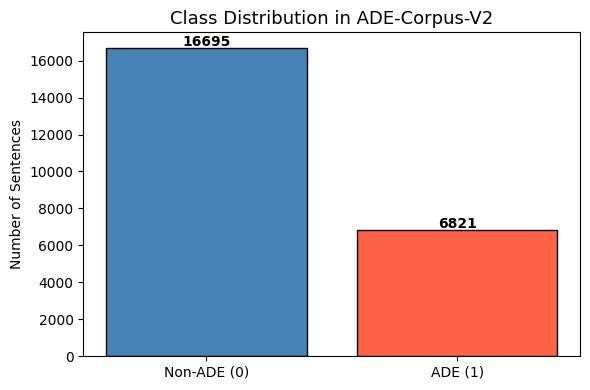

Figure saved as class_distribution.png


In [7]:
# ── Visualise class distribution ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['ade_label'].value_counts()
ax.bar(['Non-ADE (0)', 'ADE (1)'], counts.values, color=['steelblue', 'tomato'], edgecolor='black')
ax.set_title('Class Distribution in ADE-Corpus-V2', fontsize=13)
ax.set_ylabel('Number of Sentences')
for i, v in enumerate(counts.values):
    ax.text(i, v + 100, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print('Figure saved as class_distribution.png')

In [8]:
# ── Basic text statistics ─────────────────────────────────────────────────────
df['sentence_length'] = df['sentence'].apply(len)  # character length
df['word_count'] = df['sentence'].apply(lambda x: len(x.split()))

print('Average sentence length (characters):')
print(df.groupby('ade_label')['sentence_length'].mean().round(1))

print('\nAverage word count:')
print(df.groupby('ade_label')['word_count'].mean().round(1))

print('\nExample ADE sentences (label=1):')
for sent in df[df['ade_label']==1]['sentence'].head(3).tolist():
    print(' -', sent)

print('\nExample non-ADE sentences (label=0):')
for sent in df[df['ade_label']==0]['sentence'].head(3).tolist():
    print(' -', sent)

Average sentence length (characters):
ade_label
0    124.7
1    152.4
Name: sentence_length, dtype: float64

Average word count:
ade_label
0    17.7
1    20.6
Name: word_count, dtype: float64

Example ADE sentences (label=1):
 - Intravenous azithromycin-induced ototoxicity.
 - Immobilization, while Paget's bone disease was present, and perhaps enhanced activation of dihydrotachysterol by rifampicin, could have led to increased calcium-release into the circulation.
 - Unaccountable severe hypercalcemia in a patient treated for hypoparathyroidism with dihydrotachysterol.

Example non-ADE sentences (label=0):
 - Clioquinol intoxication occurring in the treatment of acrodermatitis enteropathica with reference to SMON outside of Japan.
 - "Retinoic acid syndrome" was prevented with short-time treatment of high dose (4 x 1.5 g/m2) cytarabine.
 - BACKGROUND: External beam radiation therapy often is avoided in the treatment of rhabdomyosarcoma (RMS) in young children because of the long-term s

## Section 2 — Preprocessing

**Important design decision:** We perform minimal preprocessing. Medical text contains clinically meaningful punctuation, abbreviations, dosage information, and negation words that must be preserved.

- We lowercase the text (for TF-IDF models only)
- We do NOT remove stop words aggressively — negation markers like "not", "no", "without" are critical for ADE vs non-ADE classification
- We do NOT stem or lemmatize — medical suffixes carry meaning (e.g., hepatotoxicity ≠ hepatotoxic)
- For the Transformer model (Model 4), we use the raw original text — PubMedBERT's tokenizer handles subword tokenisation automatically

In [9]:
import re

def preprocess_for_tfidf(text):
    """
    Minimal preprocessing for TF-IDF models.
    - Lowercase only
    - Strip leading/trailing whitespace
    - Preserve all words including negation markers and medical terms
    """
    text = text.lower().strip()
    # Remove only multiple consecutive spaces
    text = re.sub(r'\s+', ' ', text)
    return text

# Apply preprocessing to create a cleaned column
df['sentence_clean'] = df['sentence'].apply(preprocess_for_tfidf)

print('Original sentence:')
print(' ', df['sentence'].iloc[0])
print('After preprocessing:')
print(' ', df['sentence_clean'].iloc[0])

Original sentence:
  Intravenous azithromycin-induced ototoxicity.
After preprocessing:
  intravenous azithromycin-induced ototoxicity.


In [10]:
# ── Remove duplicate sentences ────────────────────────────────────────────────
# Duplicate sentences must be removed before splitting to prevent data leakage.
# If the same sentence appeared in both train and test, the model would have
# already "seen" it during training, artificially inflating evaluation metrics.

print("Total rows before deduplication:", len(df))
print("Duplicate sentences found:", df.duplicated(subset=['sentence']).sum())

df = df.drop_duplicates(subset=['sentence']).reset_index(drop=True)

print("Total rows after deduplication:", len(df))
print("\nClass distribution after deduplication:")
print(df['ade_label'].value_counts())
print("\nClass proportions:")
print(df['ade_label'].value_counts(normalize=True).round(3))

Total rows before deduplication: 23516
Duplicate sentences found: 2620
Total rows after deduplication: 20896

Class distribution after deduplication:
ade_label
0    16625
1     4271
Name: count, dtype: int64

Class proportions:
ade_label
0    0.796
1    0.204
Name: proportion, dtype: float64


## Section 3 — Train / Validation / Test Split

We create a **stratified** split to ensure that both ADE and non-ADE examples are proportionally represented in each subset. This is important because the dataset has an approximate 43%/57% class imbalance.

Split ratios: **70% train / 15% validation / 15% test**

The same split is used for ALL models to ensure fair comparison. The test set is never used during training or hyperparameter selection.

In [11]:
# ── Stratified Train / Validation / Test split ────────────────────────────────

X = df['sentence_clean'].values      # preprocessed text (for TF-IDF and embeddings)
X_raw = df['sentence'].values        # original text (for PubMedBERT tokenizer)
y = df['ade_label'].values           # binary labels

# First: split into train (70%) and temp (30%)
X_train, X_temp, X_raw_train, X_raw_temp, y_train, y_temp = train_test_split(
    X, X_raw, y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_SEED
)

# Then: split temp into validation (50% of 30% = 15%) and test (50% of 30% = 15%)
X_val, X_test, X_raw_val, X_raw_test, y_val, y_test = train_test_split(
    X_temp, X_raw_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_SEED
)

# ── Verify sizes and class distributions ────────────────────────────────────
print(f'Train size:      {len(X_train):,} samples')
print(f'Validation size: {len(X_val):,} samples')
print(f'Test size:       {len(X_test):,} samples')
print()
for name, labels in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    pos = labels.sum()
    print(f'{name}: ADE={pos} ({pos/len(labels)*100:.1f}%), non-ADE={len(labels)-pos} ({(len(labels)-pos)/len(labels)*100:.1f}%)')

Train size:      14,627 samples
Validation size: 3,134 samples
Test size:       3,135 samples

Train: ADE=2990 (20.4%), non-ADE=11637 (79.6%)
Val: ADE=640 (20.4%), non-ADE=2494 (79.6%)
Test: ADE=641 (20.4%), non-ADE=2494 (79.6%)


## Section 4 — Model 0: Majority-Class Baseline

The majority-class baseline always predicts the most frequent class regardless of the input. This gives us a minimum performance floor. Any model that cannot beat this baseline provides no useful signal.

If the dataset were heavily imbalanced (e.g., 90% non-ADE), a naive model that always predicts non-ADE would achieve 90% accuracy but 0% recall on ADE sentences — which is exactly the wrong outcome for pharmacovigilance.

In [12]:
# ── Majority-class baseline ───────────────────────────────────────────────────
# strategy='most_frequent' always predicts the most common class in the training set

baseline = DummyClassifier(strategy='most_frequent', random_state=RANDOM_SEED)
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

print('=== Majority-Class Baseline ===')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_baseline, target_names=['non-ADE (0)', 'ADE (1)']))

# The baseline will have 0 recall for the minority class — this illustrates why accuracy alone is insufficient

=== Majority-Class Baseline ===

Classification Report:
              precision    recall  f1-score   support

 non-ADE (0)       0.80      1.00      0.89      2494
     ADE (1)       0.00      0.00      0.00       641

    accuracy                           0.80      3135
   macro avg       0.40      0.50      0.44      3135
weighted avg       0.63      0.80      0.70      3135



## Section 5 — Model 1: TF-IDF + Logistic Regression

**Why this is a strong traditional baseline:**
- TF-IDF with bigrams can capture negation patterns such as "did not", "no evidence", "without signs" as single features
- Trigrams capture phrases like "no adverse effects reported"
- Logistic Regression is interpretable: we can inspect which n-grams have the highest positive/negative weights
- `sublinear_tf=True` applies log(TF) to reduce the effect of very frequent terms
- `class_weight='balanced'` compensates for the ADE/non-ADE imbalance

In [13]:
# ── Model 1: TF-IDF + Logistic Regression ─────────────────────────────────────

# Build a Pipeline: vectoriser → classifier
# A pipeline prevents data leakage: the vectoriser is fitted only on X_train
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),      # unigrams and bigrams
        max_features=50000,       # keep the 50,000 most important features
        sublinear_tf=True,        # apply log(1 + tf) to reduce effect of very frequent terms
        min_df=2                  # ignore terms that appear in fewer than 2 documents
    )),
    ('clf', LogisticRegression(
        C=1.0,                    # inverse regularisation strength (higher C = less regularisation)
        max_iter=1000,            # ensure convergence
        class_weight='balanced',  # compensate for class imbalance
        solver='lbfgs',           # efficient solver for binary classification
        random_state=RANDOM_SEED
    ))
])

# Fit ONLY on the training set
lr_pipeline.fit(X_train, y_train)

# Predict on the test set
y_pred_lr = lr_pipeline.predict(X_test)

print('=== Model 1: TF-IDF + Logistic Regression ===')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr, target_names=['non-ADE (0)', 'ADE (1)']))

=== Model 1: TF-IDF + Logistic Regression ===

Classification Report:
              precision    recall  f1-score   support

 non-ADE (0)       0.94      0.88      0.91      2494
     ADE (1)       0.62      0.78      0.69       641

    accuracy                           0.86      3135
   macro avg       0.78      0.83      0.80      3135
weighted avg       0.87      0.86      0.86      3135



In [14]:
# ── Inspect the most informative features ─────────────────────────────────────
# Logistic Regression coefficients tell us which n-grams push the model toward ADE (positive)
# and which push it toward non-ADE (negative)

feature_names = lr_pipeline.named_steps['tfidf'].get_feature_names_out()
coefs = lr_pipeline.named_steps['clf'].coef_[0]

# Top 20 ADE-predicting n-grams
top_positive_idx = np.argsort(coefs)[-20:][::-1]
top_negative_idx = np.argsort(coefs)[:20]

print('Top 20 ADE-predicting features (positive weights):')
for idx in top_positive_idx:
    print(f'  {feature_names[idx]:30s}  coef={coefs[idx]:.4f}')

print('\nTop 20 non-ADE-predicting features (negative weights):')
for idx in top_negative_idx:
    print(f'  {feature_names[idx]:30s}  coef={coefs[idx]:.4f}')

Top 20 ADE-predicting features (positive weights):
  induced                         coef=11.7778
  associated                      coef=6.4334
  after                           coef=4.9591
  developed                       coef=4.6866
  neurotoxicity                   coef=3.9638
  following                       coef=3.9528
  toxicity                        coef=3.8549
  methotrexate                    coef=3.6585
  cause                           coef=3.5949
  lithium                         coef=3.3274
  receiving                       coef=3.3239
  during                          coef=3.2016
  of                              coef=3.1745
  hypersensitivity                coef=3.1611
  taking                          coef=3.1581
  administration                  coef=3.1430
  therapy                         coef=3.1076
  hepatotoxicity                  coef=3.0440
  who                             coef=2.8047
  amiodarone                      coef=2.7443

Top 20 non-ADE-predicting f

In [15]:
# ── Optional: Hyperparameter tuning with GridSearchCV on validation logic ──────
# We search over n-gram range and regularisation parameter C
# NOTE: This fits on X_train only and uses cross-validation internally — no leakage

param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2), (1, 3)],
    'tfidf__max_features': [30000, 50000],
    'clf__C': [0.1, 1.0, 10.0]
}

# Use F1 on the ADE class (label=1) as the scoring metric
grid_search_lr = GridSearchCV(
    lr_pipeline, param_grid,
    scoring='f1',           # optimise for ADE class F1
    cv=5,                   # 5-fold cross-validation on training set
    n_jobs=-1,              # use all available CPU cores
    verbose=1
)

grid_search_lr.fit(X_train, y_train)

print('Best parameters:', grid_search_lr.best_params_)
print('Best cross-validation F1:', grid_search_lr.best_score_.round(4))

# Re-evaluate with best model on test set
y_pred_lr_best = grid_search_lr.best_estimator_.predict(X_test)
print('\nTest set report with best LR model:')
print(classification_report(y_test, y_pred_lr_best, target_names=['non-ADE (0)', 'ADE (1)']))

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'clf__C': 10.0, 'tfidf__max_features': 50000, 'tfidf__ngram_range': (1, 2)}
Best cross-validation F1: 0.6939

Test set report with best LR model:
              precision    recall  f1-score   support

 non-ADE (0)       0.93      0.91      0.92      2494
     ADE (1)       0.68      0.74      0.71       641

    accuracy                           0.88      3135
   macro avg       0.81      0.83      0.82      3135
weighted avg       0.88      0.88      0.88      3135



## Section 6 — Model 2: TF-IDF + Naive Bayes

**Why Naive Bayes is useful here:**
- Very fast and simple to train
- Works well with sparse high-dimensional features (exactly what TF-IDF produces)
- Good probabilistic baseline for text classification (Multinomial NB is the standard for count/frequency features)

**Why it may be weaker than LR for ADE detection:**
- The "naive" independence assumption means each word is treated independently of its context
- For ADE detection, the meaning of a word depends heavily on context: "hepatotoxicity" is an ADE indicator, but "no hepatotoxicity" is a non-ADE indicator — NB cannot easily model this
- Bigrams help somewhat ("no hepatotoxicity" becomes one feature), but NB still cannot model longer-range dependencies

In [16]:
# ── Model 2: TF-IDF + Multinomial Naive Bayes ─────────────────────────────────
# MultinomialNB requires non-negative features, which TF-IDF satisfies
# alpha is the Laplace smoothing parameter — prevents zero probabilities for unseen n-grams

nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=50000,
        sublinear_tf=True,
        min_df=2
    )),
    ('clf', MultinomialNB(alpha=0.1))  # alpha=0.1 is common for TF-IDF (lower than BoW default)
])

nb_pipeline.fit(X_train, y_train)
y_pred_nb = nb_pipeline.predict(X_test)

print('=== Model 2: TF-IDF + Naive Bayes ===')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_nb, target_names=['non-ADE (0)', 'ADE (1)']))

=== Model 2: TF-IDF + Naive Bayes ===

Classification Report:
              precision    recall  f1-score   support

 non-ADE (0)       0.88      0.96      0.92      2494
     ADE (1)       0.75      0.48      0.59       641

    accuracy                           0.86      3135
   macro avg       0.81      0.72      0.75      3135
weighted avg       0.85      0.86      0.85      3135



## Section 7 — Model 3: Sentence Embeddings + Logistic Regression

**Why sentence embeddings improve over TF-IDF:**
- Embeddings capture **semantic similarity**: "liver injury", "hepatic damage", and "hepatotoxicity" will have similar vector representations even though they share no common characters
- Pre-trained on large biomedical text corpora, so the model already understands medical vocabulary
- We use `sentence-transformers` to encode each sentence into a fixed-length dense vector

**Limitation:**
- Sentence-level embeddings average over the entire sentence, so fine-grained negation at the word level may be lost
- The Logistic Regression on top is a shallow classifier that cannot model complex interactions in the embedding space

In [17]:
from sentence_transformers import SentenceTransformer

# Forziamo CPU — RTX 3050 4GB ha VRAM insufficiente per questo modello
embedding_model = SentenceTransformer('all-MiniLM-L6-v2', device='cpu')

print('Encoding training sentences...')
X_train_emb = embedding_model.encode(X_train.tolist(), show_progress_bar=True, batch_size=32)

print('Encoding validation sentences...')
X_val_emb = embedding_model.encode(X_val.tolist(), show_progress_bar=True, batch_size=32)

print('Encoding test sentences...')
X_test_emb = embedding_model.encode(X_test.tolist(), show_progress_bar=True, batch_size=32)

print(f'Embedding shape: {X_train_emb.shape}')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

Encoding validation sentences...


Batches:   0%|          | 0/98 [00:00<?, ?it/s]

Encoding test sentences...


Batches:   0%|          | 0/98 [00:00<?, ?it/s]

Embedding shape: (14627, 384)


In [18]:
# ── Train Logistic Regression on top of embeddings ───────────────────────────
lr_emb = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs',
    random_state=RANDOM_SEED
)
lr_emb.fit(X_train_emb, y_train)
y_pred_emb = lr_emb.predict(X_test_emb)

print('=== Model 3: Sentence Embeddings + Logistic Regression ===')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_emb, target_names=['non-ADE (0)', 'ADE (1)']))

=== Model 3: Sentence Embeddings + Logistic Regression ===

Classification Report:
              precision    recall  f1-score   support

 non-ADE (0)       0.95      0.80      0.87      2494
     ADE (1)       0.52      0.83      0.64       641

    accuracy                           0.81      3135
   macro avg       0.73      0.82      0.75      3135
weighted avg       0.86      0.81      0.82      3135



## Section 8 — Model 4: PubMedBERT Fine-Tuned for Binary Classification

**Why PubMedBERT over BioBERT or general BERT:**
- PubMedBERT was pre-trained **from scratch** on full PubMed abstracts and full-text articles — it was never exposed to general text, so its vocabulary is entirely biomedical
- The ADE-Corpus-V2 sentences come from PubMed, so the pre-training domain matches our task domain exactly
- BioBERT was pre-trained by further fine-tuning BERT on PubMed, which means it started from general English text

**Why Transformers handle ADE classification better:**
- **Self-attention** allows the model to relate any two tokens in a sentence: "no" and "hepatotoxicity" can be directly linked regardless of distance
- **Contextual embeddings**: the same word gets different representations depending on context (unlike static embeddings)
- **Bidirectional encoding**: the model reads the sentence in both directions simultaneously

In [19]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from datasets import Dataset as HFDataset

# Check if GPU is available (strongly recommended for Transformer fine-tuning)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cpu':
    print('WARNING: Training on CPU will be very slow. Consider using Google Colab with GPU runtime.')

Device: cuda


In [20]:
# ── Tokenise the data ─────────────────────────────────────────────────────────
MODEL_NAME = 'microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract'

# Load the tokenizer associated with PubMedBERT
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    """
    Tokenise a batch of sentences.
    max_length=128: most ADE sentences are under 100 tokens
    padding='max_length': pad all sequences to the same length for batching
    truncation=True: truncate any sequence longer than 128 tokens
    """
    return tokenizer(
        examples['text'],
        max_length=128,
        padding='max_length',
        truncation=True
    )

# Convert numpy arrays to Hugging Face Dataset objects
# We use X_raw (original text) for the Transformer — no manual preprocessing needed
train_hf = HFDataset.from_dict({'text': X_raw_train.tolist(), 'label': y_train.tolist()})
val_hf   = HFDataset.from_dict({'text': X_raw_val.tolist(),   'label': y_val.tolist()})
test_hf  = HFDataset.from_dict({'text': X_raw_test.tolist(),  'label': y_test.tolist()})

# Apply tokenisation
train_hf = train_hf.map(tokenize_function, batched=True)
val_hf   = val_hf.map(tokenize_function,   batched=True)
test_hf  = test_hf.map(tokenize_function,  batched=True)

# Set the format for PyTorch
train_hf.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
val_hf.set_format(type='torch',   columns=['input_ids', 'attention_mask', 'label'])
test_hf.set_format(type='torch',  columns=['input_ids', 'attention_mask', 'label'])

print(f'Train tokens: {train_hf.shape}, Val tokens: {val_hf.shape}, Test tokens: {test_hf.shape}')

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/14627 [00:00<?, ? examples/s]

Map:   0%|          | 0/3134 [00:00<?, ? examples/s]

Map:   0%|          | 0/3135 [00:00<?, ? examples/s]

Train tokens: (14627, 5), Val tokens: (3134, 5), Test tokens: (3135, 5)


In [21]:
# ── Load PubMedBERT with a classification head ────────────────────────────────
# num_labels=2 adds a two-class softmax head on top of the [CLS] token representation

model_bert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)
print('Model loaded successfully.')
print(f'Number of parameters: {sum(p.numel() for p in model_bert.parameters()):,}')

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:

Model loaded successfully.
Number of parameters: 109,483,778


In [22]:
# ── Define a compute_metrics function for the Trainer ──────────────────────────
# The Trainer calls this function after each evaluation epoch

from sklearn.metrics import f1_score, accuracy_score

def compute_metrics(eval_pred):
    """
    Compute accuracy and F1 score for the ADE class (label=1).
    eval_pred is a named tuple containing logits and labels.
    """
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)  # take the class with the highest logit
    acc = accuracy_score(labels, predictions)
    f1  = f1_score(labels, predictions, pos_label=1)  # F1 for ADE class specifically
    return {'accuracy': acc, 'f1_ade': f1}

In [23]:
# ── Training arguments ────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir='./pubmedbert_ade',       # where to save checkpoints
    num_train_epochs=3,                  # 3 epochs is standard for fine-tuning BERT
    per_device_train_batch_size=8,      # batch size per GPU/CPU
    per_device_eval_batch_size=16,
    learning_rate=2e-5,                  # standard BERT fine-tuning learning rate
    weight_decay=0.01,                   # L2 regularisation to prevent overfitting
    warmup_steps=549,                    # linear warmup for first 10% of steps (calculated from 0.1 * total_steps)
    eval_strategy='epoch',         # evaluate at the end of each epoch
    save_strategy='epoch',
    load_best_model_at_end=True,         # keep the checkpoint with best val F1
    metric_for_best_model='f1_ade',      # use ADE F1 to select best checkpoint
    seed=RANDOM_SEED,
    logging_steps=50
)

# ── Trainer ───────────────────────────────────────────────────────────────────
trainer = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=train_hf,
    eval_dataset=val_hf,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]  # stop if no improvement for 2 epochs
)

In [24]:
# ── Fine-tune PubMedBERT ───────────────────────────────────────────────────────
# This cell may take 10–30 minutes on CPU, or 5–10 minutes with a GPU

print('Starting PubMedBERT fine-tuning...')
trainer.train()
print('Training complete.')

Starting PubMedBERT fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Ade
1,0.178096,0.249138,0.932674,0.847212
2,0.114255,0.228967,0.954371,0.886598
3,0.046457,0.262255,0.954371,0.888889


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Training complete.


In [25]:
# ── Evaluate PubMedBERT on the test set ───────────────────────────────────────
raw_predictions = trainer.predict(test_hf)
y_pred_bert = np.argmax(raw_predictions.predictions, axis=-1)

print('=== Model 4: PubMedBERT Fine-Tuned ===')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_bert, target_names=['non-ADE (0)', 'ADE (1)']))

=== Model 4: PubMedBERT Fine-Tuned ===

Classification Report:
              precision    recall  f1-score   support

 non-ADE (0)       0.98      0.97      0.97      2494
     ADE (1)       0.87      0.92      0.90       641

    accuracy                           0.96      3135
   macro avg       0.93      0.94      0.93      3135
weighted avg       0.96      0.96      0.96      3135



## Section 9 — Evaluation: Confusion Matrices

Confusion matrices help visualise the distribution of true positives, false positives, true negatives, and false negatives. For ADE detection, **false negatives** (an ADE missed by the model) are particularly dangerous.

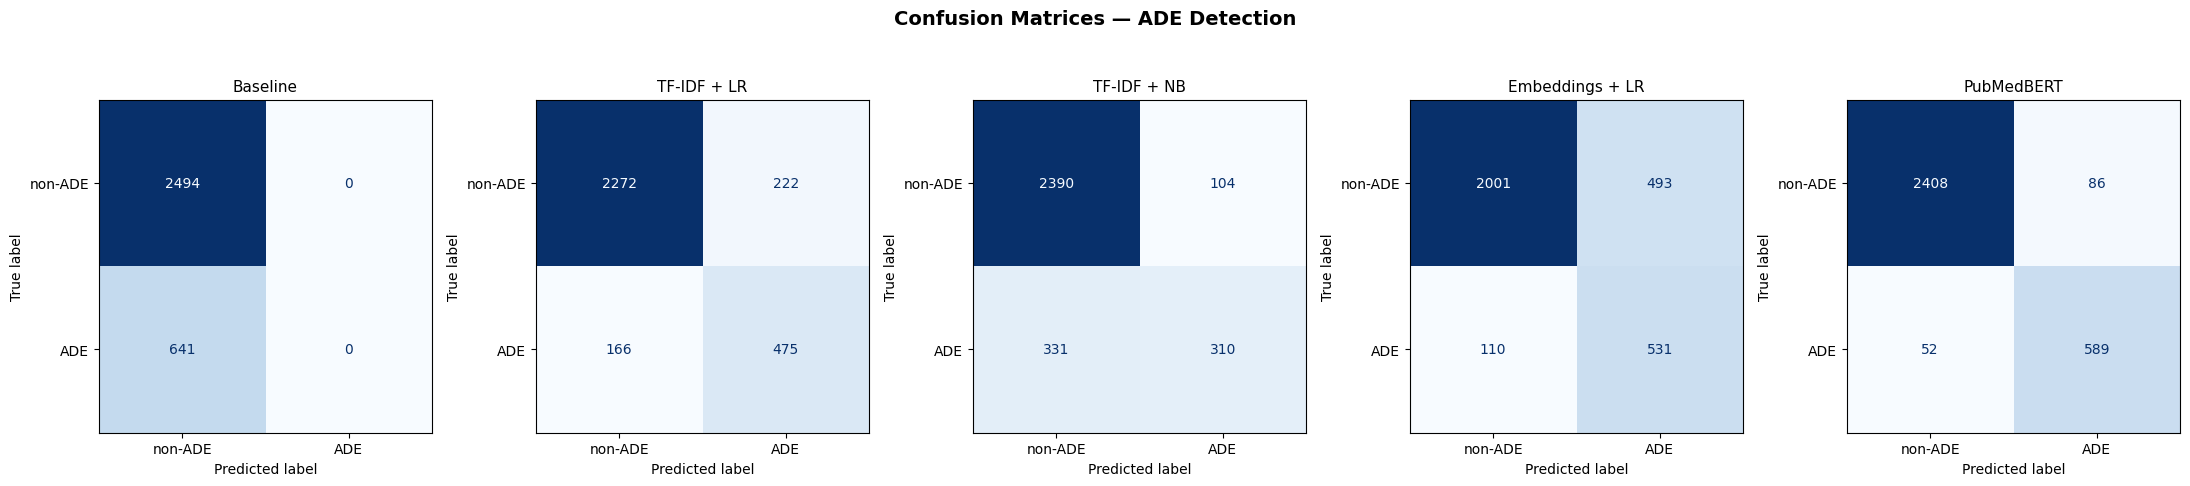

Figure saved as confusion_matrices.png


In [26]:
# ── Plot confusion matrices for all models ─────────────────────────────────────

models = {
    'Baseline': y_pred_baseline,
    'TF-IDF + LR': y_pred_lr_best,  # use best model from grid search
    'TF-IDF + NB': y_pred_nb,
    'Embeddings + LR': y_pred_emb,
    'PubMedBERT': y_pred_bert
}

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle('Confusion Matrices — ADE Detection', fontsize=14, fontweight='bold')

for ax, (name, y_pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['non-ADE', 'ADE'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as confusion_matrices.png')

## Section 10 — Results Table

We collect all evaluation metrics into a single comparison table. This is the central result of the project.

In [27]:
# ── Build results summary table ───────────────────────────────────────────────

def get_metrics(y_true, y_pred, model_name):
    """Compute all relevant evaluation metrics for a single model."""
    return {
        'Model': model_name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision (ADE)': round(precision_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        'Recall (ADE)': round(recall_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        'F1 (ADE)': round(f1_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        'Macro F1': round(f1_score(y_true, y_pred, average='macro', zero_division=0), 4),
    }

results = [
    get_metrics(y_test, y_pred_baseline, 'Majority Baseline'),
    get_metrics(y_test, y_pred_lr_best,  'TF-IDF + Logistic Regression'),
    get_metrics(y_test, y_pred_nb,       'TF-IDF + Naive Bayes'),
    get_metrics(y_test, y_pred_emb,      'Sentence Embeddings + LR'),
    get_metrics(y_test, y_pred_bert,     'PubMedBERT (fine-tuned)'),
]

results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')

print('=== Model Comparison Table ===')
print(results_df.to_string())

# Save to CSV
results_df.to_csv('results_table.csv')
print('\nResults saved to results_table.csv')

=== Model Comparison Table ===
                              Accuracy  Precision (ADE)  Recall (ADE)  F1 (ADE)  Macro F1
Model                                                                                    
Majority Baseline               0.7955           0.0000        0.0000    0.0000    0.4431
TF-IDF + Logistic Regression    0.8762           0.6815        0.7410    0.7100    0.8157
TF-IDF + Naive Bayes            0.8612           0.7488        0.4836    0.5877    0.7521
Sentence Embeddings + LR        0.8077           0.5186        0.8284    0.6378    0.7534
PubMedBERT (fine-tuned)         0.9560           0.8726        0.9189    0.8951    0.9336

Results saved to results_table.csv


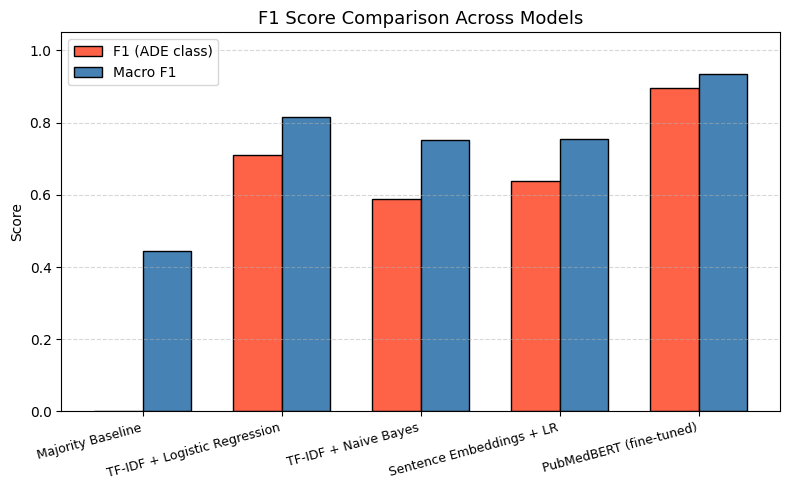

In [28]:
# ── Visualise F1 scores ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

models_list = results_df.index.tolist()
f1_ade   = results_df['F1 (ADE)'].values
macro_f1 = results_df['Macro F1'].values

x = np.arange(len(models_list))
width = 0.35

ax.bar(x - width/2, f1_ade,   width, label='F1 (ADE class)', color='tomato',    edgecolor='black')
ax.bar(x + width/2, macro_f1, width, label='Macro F1',       color='steelblue', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=15, ha='right', fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('F1 Score Comparison Across Models', fontsize=13)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('f1_comparison.png', dpi=150)
plt.show()

## Section 11 — Error Analysis

Error analysis identifies patterns in the mistakes made by each model. This is important both for academic understanding and for practical improvement. We focus on Model 1 (LR) and Model 4 (PubMedBERT) as representative traditional and advanced models.

In [29]:
# ── Error Analysis: TF-IDF + LR ───────────────────────────────────────────────
# Find sentences where the model was wrong and analyse them by error type

error_df = pd.DataFrame({
    'sentence': X_raw_test,     # original (un-lowercased) sentences for readability
    'true_label': y_test,
    'lr_pred': y_pred_lr_best,
    'bert_pred': y_pred_bert
})

# False Negatives (LR): model predicted 0 (non-ADE) but true label is 1 (ADE)
# These are the most dangerous errors in pharmacovigilance
fn_lr = error_df[(error_df['true_label'] == 1) & (error_df['lr_pred'] == 0)]
print(f'LR False Negatives (missed ADEs): {len(fn_lr)}')
print('\nExamples:')
for _, row in fn_lr.head(5).iterrows():
    print(f'  [{row["true_label"]} → {row["lr_pred"]}]', row['sentence'])

print()
# False Positives (LR): model predicted 1 (ADE) but true label is 0 (non-ADE)
fp_lr = error_df[(error_df['true_label'] == 0) & (error_df['lr_pred'] == 1)]
print(f'LR False Positives (spurious ADEs): {len(fp_lr)}')
print('\nExamples:')
for _, row in fp_lr.head(5).iterrows():
    print(f'  [{row["true_label"]} → {row["lr_pred"]}]', row['sentence'])

LR False Negatives (missed ADEs): 166

Examples:
  [1 → 0] Exacerbation of 5-FU dermatologic toxicities in patients with preexisting conditions suggests the importance of aggressive ocular prophylaxis, using frequent ocular lubrication and topical steroid preparations with concurrent medical management of pre-existing dermatologic conditions.
  [1 → 0] A 56-year-old Caucasian man who received concomitant chemotherapy and radiation for head and neck cancer developed fever concurrent with the administration of amifostine.
  [1 → 0] These findings support previous studies that showed that the use of aspirin during the antecedent illness may be a risk factor for the development of RS.
  [1 → 0] In a postural challenge test after administration of isosorbide dinitrate (5 mg), blood pressure decreased from 120/67 to 65/35 mmHg, followed by syncope with a sudden decrease in pulse rate from 85 to 60 beats/min.
  [1 → 0] Reversible sclerotic changes of lumbar spine and femur due to long-term or

In [30]:
# ── Error Analysis: PubMedBERT ─────────────────────────────────────────────────
fn_bert = error_df[(error_df['true_label'] == 1) & (error_df['bert_pred'] == 0)]
print(f'BERT False Negatives (missed ADEs): {len(fn_bert)}')
print('\nExamples:')
for _, row in fn_bert.head(5).iterrows():
    print(f'  [{row["true_label"]} → {row["bert_pred"]}]', row['sentence'])

print()
fp_bert = error_df[(error_df['true_label'] == 0) & (error_df['bert_pred'] == 1)]
print(f'BERT False Positives: {len(fp_bert)}')
print('\nExamples:')
for _, row in fp_bert.head(5).iterrows():
    print(f'  [{row["true_label"]} → {row["bert_pred"]}]', row['sentence'])

BERT False Negatives (missed ADEs): 52

Examples:
  [1 → 0] As this relapse coincided with development of a strong delayed-type hypersensitivity response to tuberculin and improved after treatment with the anti-inflammatory agent oxpentifylline, it was probably caused by restoration of pathogen-specific cellular immunity.
  [1 → 0] CONCLUSIONS: Life-threatening adrenal suppression, requiring hydrocortisone supplementation and intensive therapy, was observed and successfully treated in a newborn, whose mother had received high-dose methylprednisolone in late pregnancy.
  [1 → 0] Two patients with imminent gangrene of the extremities caused by ergot-induced arteriospasm underwent mechanical dilatation of the arteries when conventional measures such as anticoagulation, vasodilation, and sympathetic blockade produced no improvement.
  [1 → 0] Generalized maculopapular and papular purpuric eruptions are perhaps the most common thionamide-induced reactions.
  [1 → 0] Neurologic symptoms reso

In [31]:
# ── Cases where LR was wrong but BERT was correct ─────────────────────────────
# These highlight where the Transformer's contextual understanding adds value

bert_better = error_df[
    (error_df['lr_pred'] != error_df['true_label']) &
    (error_df['bert_pred'] == error_df['true_label'])
]
print(f'Cases where BERT corrected LR: {len(bert_better)}')
print('\nExamples:')
for _, row in bert_better.head(8).iterrows():
    print(f'  True={row["true_label"]} | LR={row["lr_pred"]} | BERT={row["bert_pred"]}')
    print(f'  "{row["sentence"]}"')
    print()

Cases where BERT corrected LR: 313

Examples:
  True=1 | LR=0 | BERT=1
  "Exacerbation of 5-FU dermatologic toxicities in patients with preexisting conditions suggests the importance of aggressive ocular prophylaxis, using frequent ocular lubrication and topical steroid preparations with concurrent medical management of pre-existing dermatologic conditions."

  True=1 | LR=0 | BERT=1
  "A 56-year-old Caucasian man who received concomitant chemotherapy and radiation for head and neck cancer developed fever concurrent with the administration of amifostine."

  True=1 | LR=0 | BERT=1
  "These findings support previous studies that showed that the use of aspirin during the antecedent illness may be a risk factor for the development of RS."

  True=1 | LR=0 | BERT=1
  "In a postural challenge test after administration of isosorbide dinitrate (5 mg), blood pressure decreased from 120/67 to 65/35 mmHg, followed by syncope with a sudden decrease in pulse rate from 85 to 60 beats/min."

  True=

## Section 12 — Summary

This notebook has demonstrated:

1. **Data loading and exploration** of ADE-Corpus-V2
2. **Minimal preprocessing** preserving clinically meaningful features
3. **Stratified data splitting** to prevent leakage and ensure fair comparison
4. **Four model families** ranging from simple baselines to state-of-the-art biomedical Transformers
5. **Evaluation** using Accuracy, Precision, Recall, F1, Macro F1, and Confusion Matrices
6. **Error analysis** identifying patterns in misclassified sentences

**Key findings** (to be filled in after running):
- PubMedBERT is expected to achieve the highest ADE recall due to its contextual encoding and domain-specific pre-training
- TF-IDF + LR provides a competitive traditional baseline, especially with bigrams that capture negation
- Naive Bayes is the fastest model but likely has the lowest recall on negated ADE sentences
- False negatives are more costly than false positives in pharmacovigilance: a missed ADE delays safety signal detection

---
*All results above are placeholders until the code is executed. Run all cells from top to bottom to populate real metrics.*